Date         datetime64[ns]
Open                 object
High                float64
Low                 float64
Close               float64
Adj Close           float64
Volume              float64
dtype: object

Date          0
Open          0
High         40
Low          40
Close        40
Adj Close    40
Volume       40
dtype: int64

,Date,High,Low,Close,Adj Close,Volume
count,2595,2555.000000,2555.000000,2555.000000,2555.000000,2.555000e+03
mean,2020-01-29 04:48:33.294797568,340.841554,337.025092,339.067562,317.353139,8.683163e+07
min,2015-01-02 00:00:00,184.100000,181.020000,182.860000,156.330000,2.027000e+07
25%,2017-07-17 12:00:00,244.580000,242.735000,243.710000,214.545000,5.826740e+07
50%,2020-01-30 00:00:00,306.190000,300.620000,303.300000,279.750000,7.616040e+07
75%,2022-08-11 12:00:00,427.150000,421.125000,424.815000,407.990000,1.013163e+08
max,2025-02-28 00:00:00,613.230000,609.560000,612.930000,611.090000,5.072443e+08
std,NaN,112.413972,111.271018,111.887665,119.784158,4.486657e+07


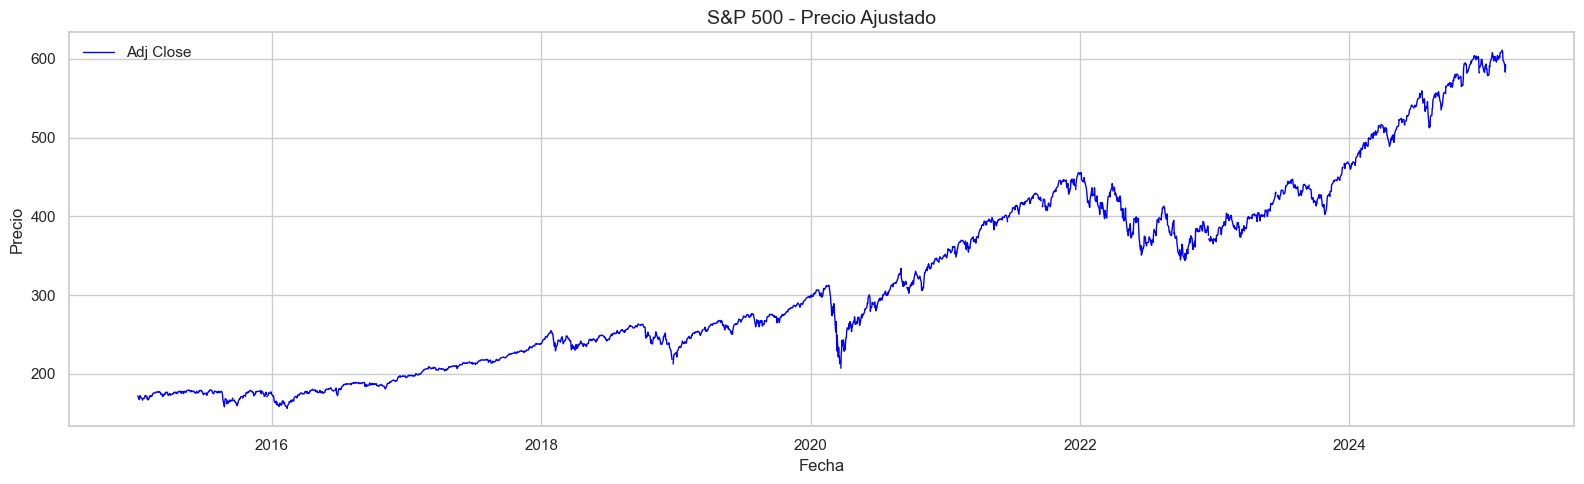

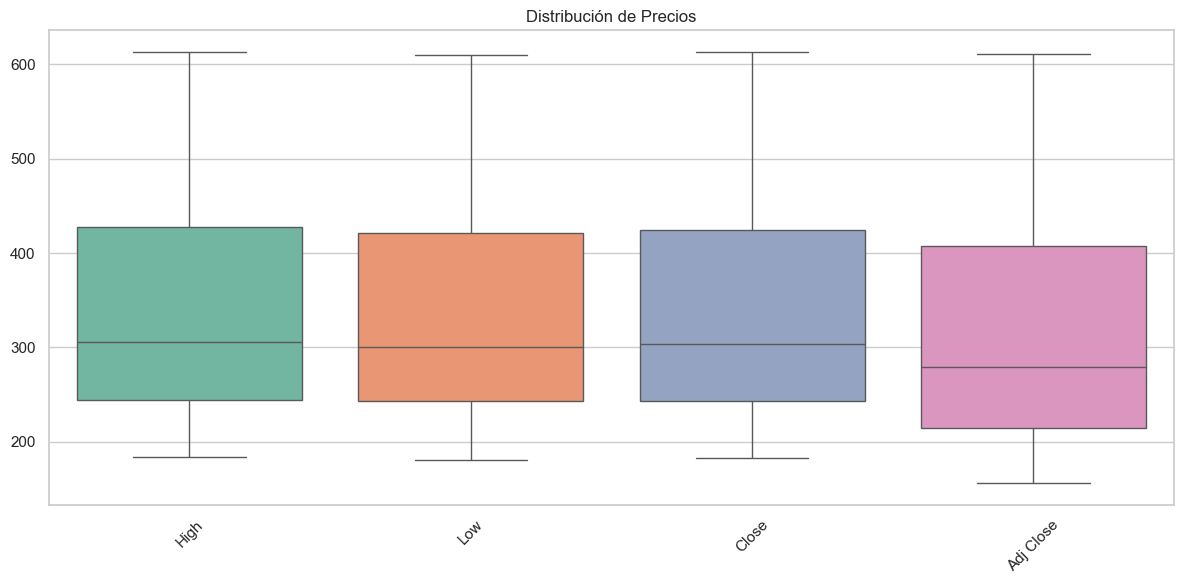

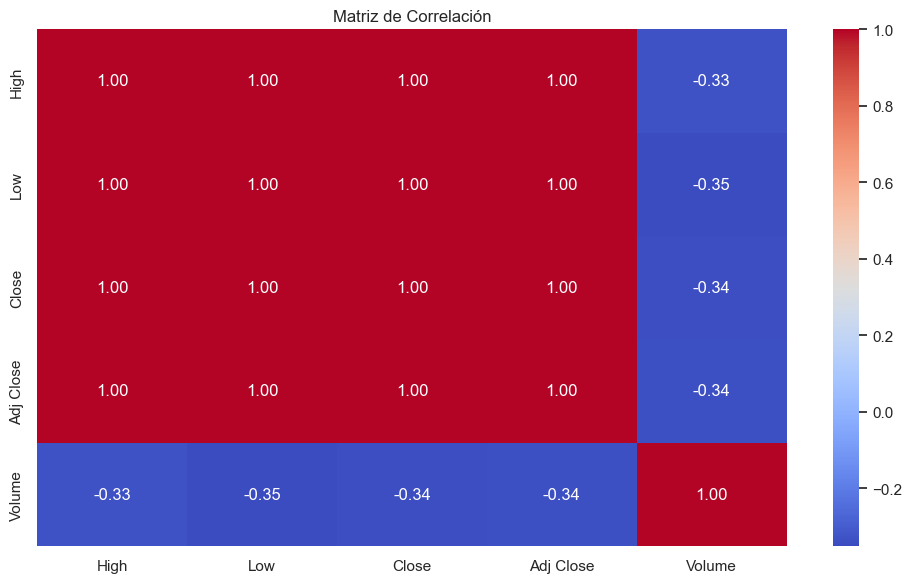

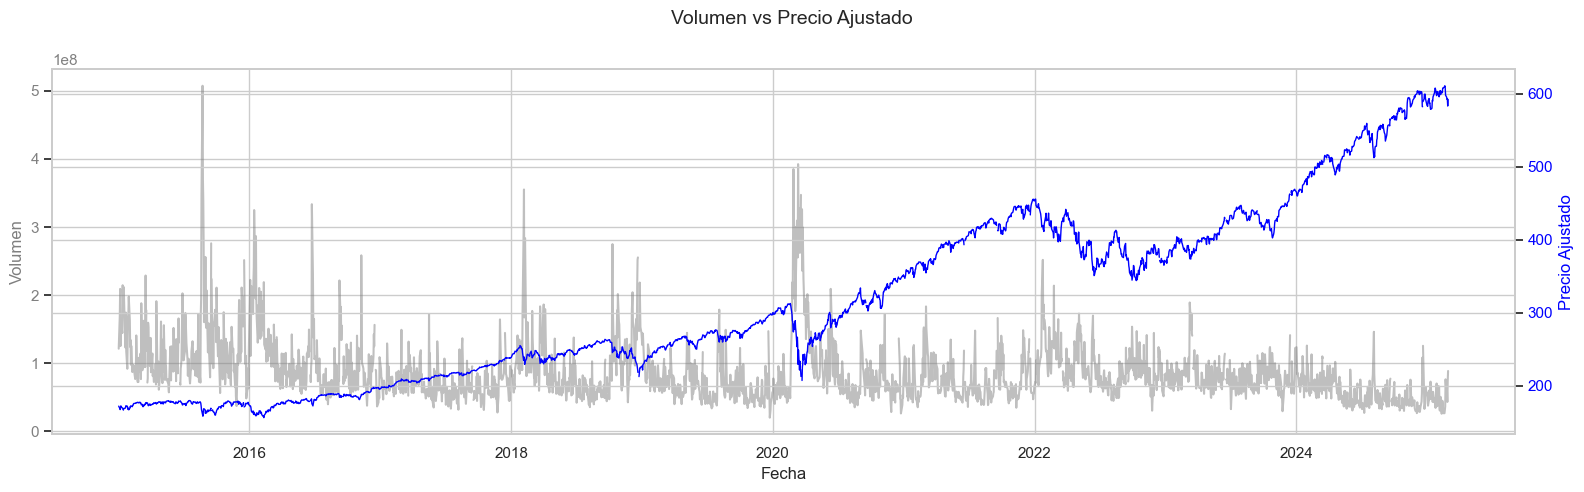

FileNotFoundError: [Errno 2] No such file or directory: 'QQQ.csv'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
sns.set_context("notebook")

# === Función para cargar ===
def cargar_datos(path):
    df = pd.read_csv(path)
    df.columns = [col.strip() for col in df.columns]
    df['Date'] = pd.to_datetime(df['Date'])
    df.sort_values('Date', inplace=True)
    return df

# === Resumen ===
def resumen_general(df):
    display(df.dtypes)
    display(df.isnull().sum())
    display(df.describe())

# === Gráfico estilo NASDAQ 100 ===
def graficos_linea(df, titulo='Precio Ajustado'):
    fig, ax = plt.subplots(figsize=(16, 5))
    ax.plot(df['Date'], df['Adj Close'], color='blue', linewidth=1, label='Adj Close')
    ax.set_title(titulo, fontsize=14)
    ax.set_xlabel('Fecha')
    ax.set_ylabel('Precio')
    ax.legend(loc='upper left')
    ax.grid(True)
    fig.tight_layout()
    plt.show()

# === Boxplot clásico para precios ===
def graficos_cajas(df):
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df[['Open', 'High', 'Low', 'Close', 'Adj Close']])
    plt.title('Distribución de Precios')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# === Mapa de correlación ===
def graficos_correlacion(df):
    plt.figure(figsize=(10, 6))
    corr = df.select_dtypes(include=[np.number]).corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Matriz de Correlación')
    plt.tight_layout()
    plt.show()

# === Relación volumen vs precio ===
def volumen_vs_precio(df):
    fig, ax1 = plt.subplots(figsize=(16, 5))

    ax1.set_xlabel('Fecha')
    ax1.set_ylabel('Volumen', color='tab:gray')
    ax1.plot(df['Date'], df['Volume'], color='gray', alpha=0.5, label='Volumen')
    ax1.tick_params(axis='y', labelcolor='gray')

    ax2 = ax1.twinx()
    ax2.set_ylabel('Precio Ajustado', color='blue')
    ax2.plot(df['Date'], df['Adj Close'], color='blue', linewidth=1, label='Adj Close')
    ax2.tick_params(axis='y', labelcolor='blue')

    fig.suptitle('Volumen vs Precio Ajustado', fontsize=14)
    fig.tight_layout()
    plt.show()

# === Cargar y ejecutar ===

# Cambia los nombres si es necesario según tu entorno local
df_sp500 = cargar_datos("../data/RAW/SPY.csv")
resumen_general(df_sp500)
graficos_linea(df_sp500, titulo='S&P 500 - Precio Ajustado')
graficos_cajas(df_sp500)
graficos_correlacion(df_sp500)
volumen_vs_precio(df_sp500)

df_nasdaq = cargar_datos("QQQ.csv")
resumen_general(df_nasdaq)
graficos_linea(df_nasdaq, titulo='NASDAQ 100 - Precio Ajustado')
graficos_cajas(df_nasdaq)
graficos_correlacion(df_nasdaq)
volumen_vs_precio(df_nasdaq)
